In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
#Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],         # number of boosting rounds
    'max_depth': [3, 6, 10],            # max tree depth
    'learning_rate': [0.01, 0.1, 0.2],  # How much each tree corrects the previous one
    'subsample': [0.8, 1.0],            # Fraction of rows to sample for each tree [1 = all]
    'colsample_bytree': [0.8, 1.0]      # Fraction of features to use per tree
}

#can expect 72 combos


In [3]:
#GridSearchCV
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',  # optimize for R²
    verbose=1,
    n_jobs=-1  # Use all cores for faster search
)

In [4]:
#Fit on Training data
# Load training features and target from previous split
X_train = pd.read_csv("dataSplits/X_train.csv")
y_train = pd.read_csv("dataSplits/y_train.csv").squeeze()  # to convert DataFrame -> Series
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 6, ...], 'n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [5]:
#Show Best Parameters & Score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated R²:", grid_search.best_score_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validated R²: 0.9430721849790931


In [ ]:
#Evaluate Final Model on Test Set
# Use best model from tuning
best_xgb = grid_search.best_estimator_

X_test = pd.read_csv("dataSplits/X_test.csv")
y_test = pd.read_csv("dataSplits/y_test.csv").squeeze()  # to convert DataFrame -> Series
# Predict on test set
y_pred = best_xgb.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nFinal Evaluation on Test Set:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")



 Final Evaluation on Test Set:
MAE:  0.0398
RMSE: 0.1869
R²:   0.9829


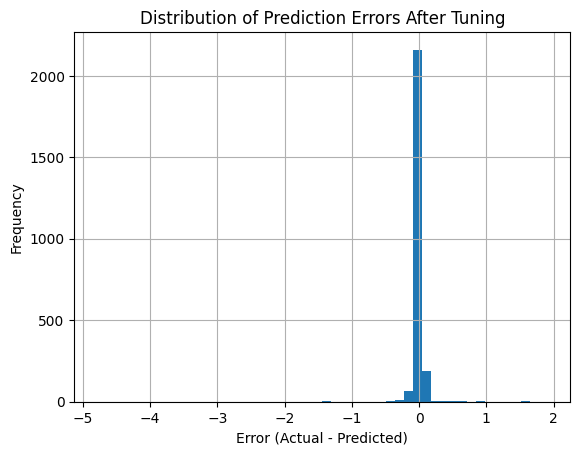

In [9]:
import matplotlib.pyplot as plt

#Analyzing Prediction Errors
errors = y_test - y_pred
plt.hist(errors, bins=50)
plt.title("Distribution of Prediction Errors After Tuning")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
